# Finding the Fair Folk

Kylie King (Georgetown University)

## Abstract

The purpose of this project is to investigate whether Ireland is caring for its historic fairy habitats. Because fairies are notorious for obstructing data collection and interfering with computer calculations, there is very little data available on fairy habitats and their preservation. This is a two-part project, where we first determine where fairies prefer to live, and then assess whether their preferred habitat is flourishing. Data collected (with much sacrifice) on the location of fairy barrows (homes) will be converted into a density layer to determine where fairy barrows are most densely clustered. Next, land cover data from 1990 will be compared to the barrow density to determine which habitat fairies prefer. To test whether fairies cluster near stone circles, rather than a particular habitat, a will be done on the average distance of fairy barrows from nearby stone circles. The preferred habitat for stone circles will also be noted. Finally, land cover data from 2018 will be compared to the 1990 dataset, to produce a change matrix, and identify whether Irish fairy habitat remains intact.

## Introduction

Ireland’s human inhabitants share the land with a cryptic, fickle, whimsical species known as the Aes Sídhe. They are also known as the Wee Folk, the Good People, the Fair Folk, or, most generally, fairies. The ancient name, Aes Sídhe, means *folk of the fairy mounds* or *folk of the barrows,* referring to the mounds the fairies live in. These mounds, also known as barrows, are found throughout Ireland, and are regarded with superstition and reverence. This caution is well-founded, as those who disturb or damage these mounds are punished with extensive bad luck and guaranteed disaster.

Unfortunately, the secreteive (and vengeful) nature of the Folk makes them difficult to study. As a result, modern researchers know very little about their preferred habitats, and the growing climate crisis is leading to worries about habitat suitability for Ireland’s Good Neighbors (another moniker). Restless fairies are prone to violent outbursts, which presents a danger to Ireland’s human inhabitants.

This study will use the little data we have to determine if fairies have a preferred habitat, and extend that finding to assess whether Ireland is properly preserving that preferred habitat. If the author survives to the completion of this study, it may offer important insights about the future of humanity’s relationship with our fairy neighbors.

The hypotheses tested in this study are as follows: (ok so we need a way to say “yeah this was proven wrong, so we pivoted!”)

Null Hypothesis: Fairies in the Republic of Ireland display no significant clustering in home locations, indicating no preference in habitat.

Hypothesis 1: Fairies in the Republic of Ireland prefer forested habitats.

Hypothesis 2: Fairies in the Republic of Ireland prefer to live near stone circles.

Hypothesis 3: Stone circles were built in a certain habitat, reflecting the nature of the fairy realm on the other side.

(fairies prefer to live in separate habitats than their hunting habitats, indicating a deep misunderstanding in fairy ecology)

# Literature Review

mostly talking about stories about fairies, for funsies things to establish: - We’re only talking about the republic of ireland because, while fairies do not recognize international borders, the republic of ireland and northern ireland have different relationships with their respective Fair Folk - we think Irish fairies will prefer forest habitats - barrows data = fairy homes - we also think they might prefer homes that are closer to stone circles - stone circles data = portals to the ethereal realm or whatever its called in irish folklore - fairies will be mad if their habitats degrade - there is evidence that they may tamper with our data, which should be anticiapted - There is also evidence that stories about fairies may be misleading - for the nonbelievers, which will actually go at the end

barrows: “Barrows are typically defined as circular enclosures of earth and/or stone, often featuring a bank and ditch, though there are also examples without these features, consisting only of a simple mound. The interior of a barrow can take the form of a flat platform or shallow depression, but the most common type found in Ireland is the ring barrow. These barrows feature a low mound that rises gradually from the enclosing ditch and have an overall diameter of 15 to 25 meters.”

stone circles: “These circles are characterised by the presence of standing stones, typically made of sandstone or quartz, that are arranged in a circular pattern. Stone circles can range in size from a few metres to over 100 metres in diameter, and they are thought to have served a variety of religious, cultural, and astronomical purposes.”

# Methodology

To test our hypotheses, the locations of fairy barrows will be compared to land cover data from 1990 to determine whether fairies prefer a certain habitat (first-order clustering). To test whether fairies cluster near stone circles (second-order clustering), rather than a particular habitat, we will compare the average distance of fairy barrows to nearby stone circles. The preferred habitat for stone circle construction will also be tested with the same land cover data, as we have very little information about fairy habits. If any preferred habitats are found, land cover data from 2018 will be compared to the 1990 dataset to produce a change matrix, and identify whether fairy habitat in the Repulic of Ireland remains intact.

## Point Data Preparation

This study was conducted using R, with the packages tidyverse, sf, mapview, spatstat, stars, rnaturalearth, terra, tidyterra, and pbapply.

The Coordinate Reference System (CRS) for this study is the Irish Transverse Mercator (ITM) projection, with EPSG code 2157. All data is reprojected or transformed into this CRS for calculations and visualizations. (cite)

The ‘barrows’ and ‘stone circles’ point data were both downloaded from IrishArchaeology.org.(cite) This website hosts downloadable kml webmaps for archeaological sites all across Ireland. Unfortunately, the website’s author, Eamonn, traded his last name to the Fair Folk, so is unidentifiable beyond the website. However, his great sacrifice is the reason the point data remains accessible and uncorrupted. More notes on the raw data can be found in the Appendix(link). The data is displayed on the interactive viewer below.

In [ ]:
library(tidyverse) |> suppressPackageStartupMessages()
library(sf) |> suppressPackageStartupMessages()
library(mapview) |> suppressPackageStartupMessages()
library(spatstat) |> suppressPackageStartupMessages()
library(stars) |> suppressPackageStartupMessages()
library(rnaturalearth) |> suppressPackageStartupMessages()
library(terra) |> suppressPackageStartupMessages()
library(tidyterra) |> suppressPackageStartupMessages()
library(pbapply) |> suppressPackageStartupMessages()
set.seed(6805)

In [ ]:
#barrows
barrows_df <- read_csv('data/raw/barrows.csv')

New names:
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`

e.g.:
  dat <- vroom(...)
  problems(dat)

Rows: 3832 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): townland, county, smrs, entity_id, class_code, monument_type, web_n...
dbl (3): objectid, latitude, longitude
lgl (3): ...11, ...12, ...15

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 222 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): townland, county, entity_id, class_code, monument_type, web_notes, ...
dbl (2): latitude, longitude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

The observation window for this study is the Natural Earth Data Republic of Ireland sf object at 1:10m resolution. All calculations are constrained to the bounds of this polygon. (cite)

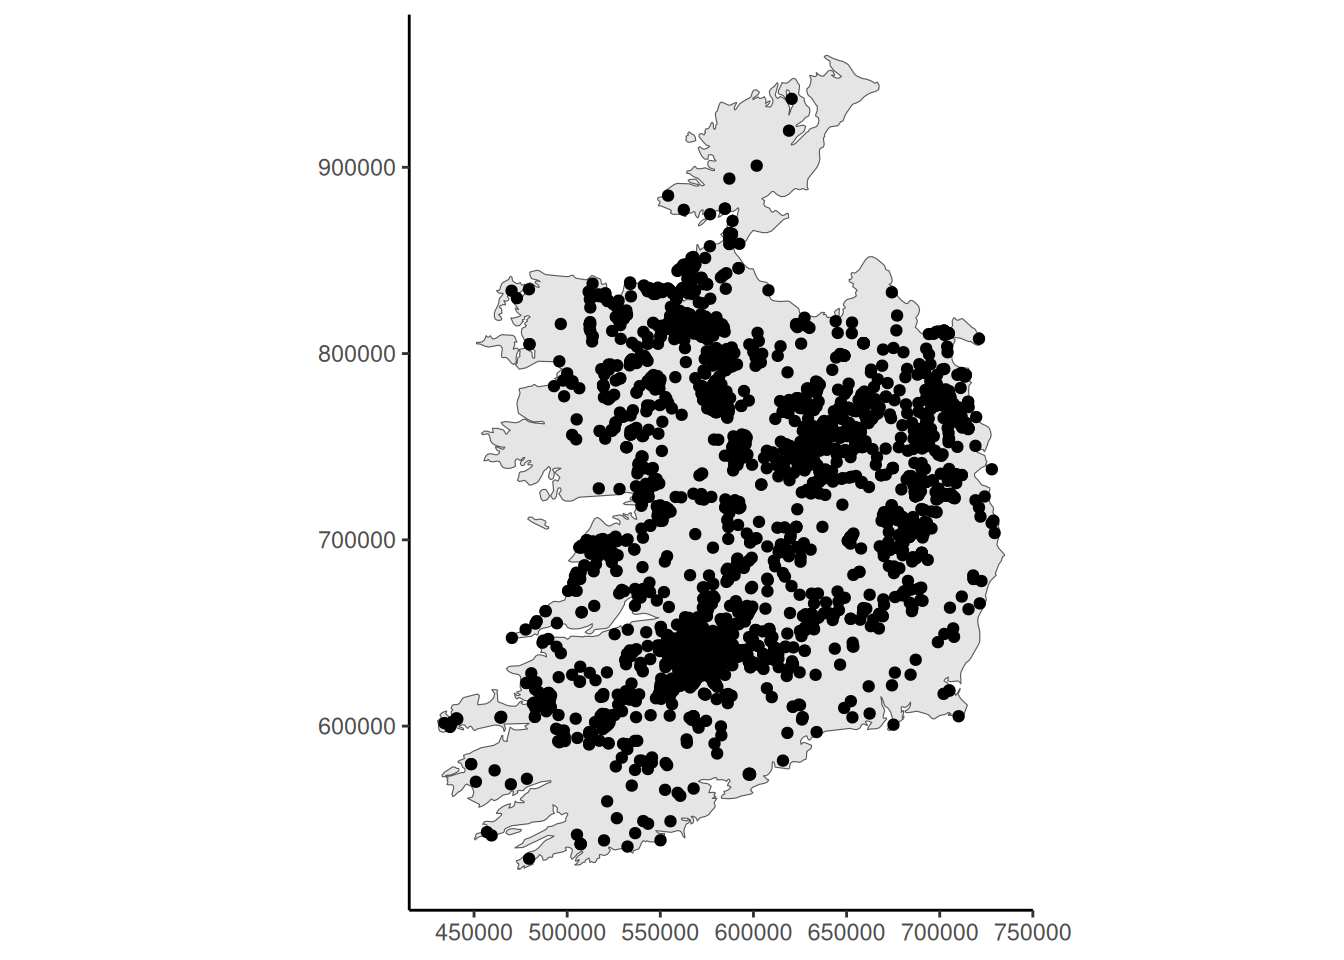

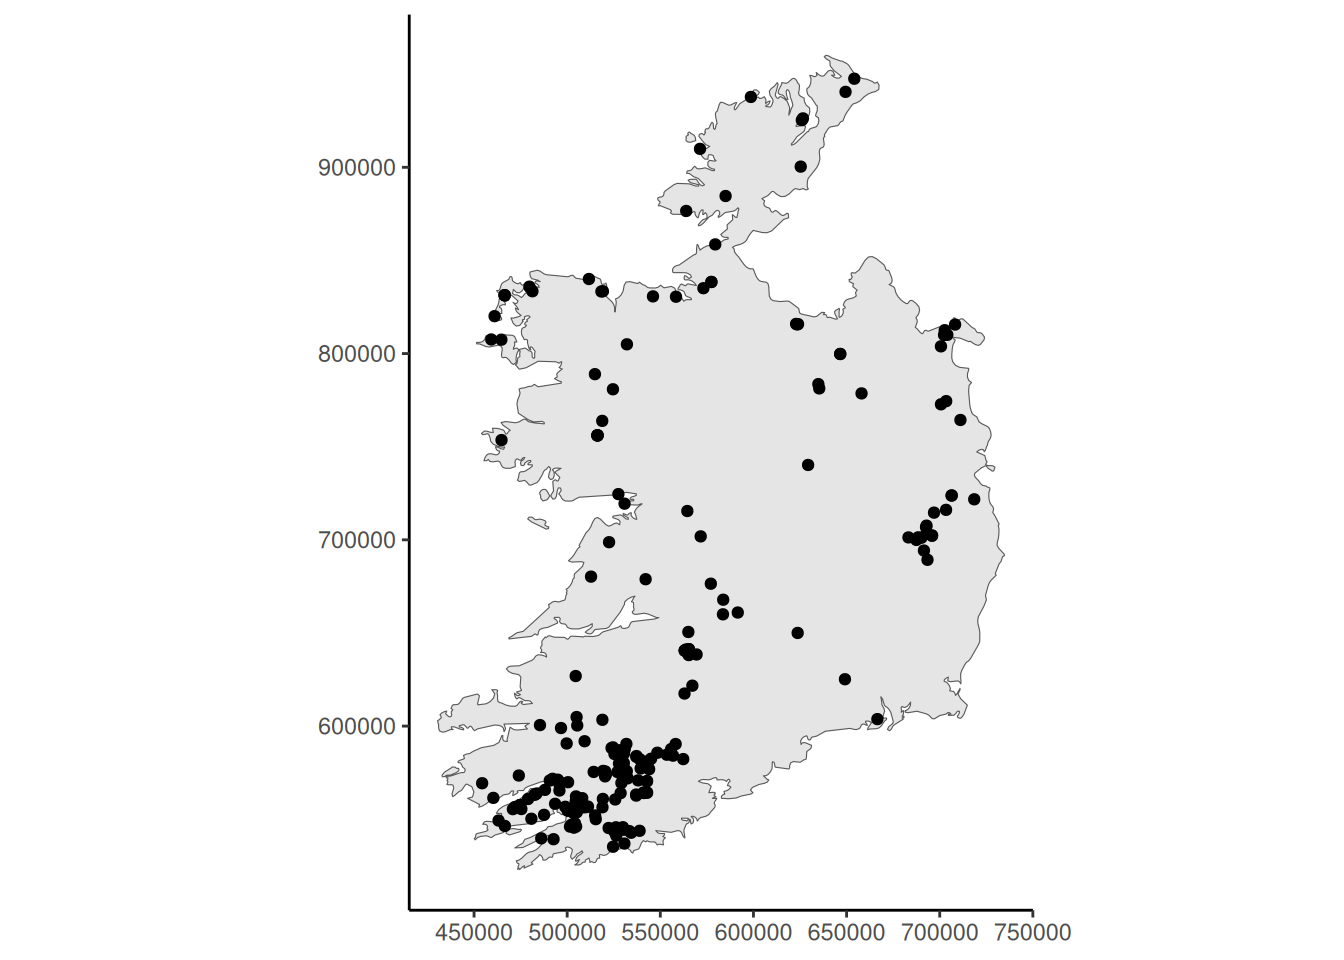

In [ ]:
#ireland observation window

ireland <- ne_countries(country = "ireland", scale="large") |> select(name,geometry)
ireland <- ireland |> sf::st_transform(2157)

#ppp charts
barrows_sf <- barrows_sf |> sf::st_transform(2157)
#some of the points are outside my ireland shapefile, so I am going to remove them (since I have thousands)
barrows_sf <- barrows_sf[st_within(barrows_sf, ireland, sparse = FALSE), ] 
barrows_ppp <- as.ppp(barrows_sf, W=as.owin(ireland)) 

The point data was loaded from CSV format to planar point pattern format, as displayed below. These point patterns will later be used to perform fairy barrow density calculations and stone circle distance calculations in the hypothesis testing phase.

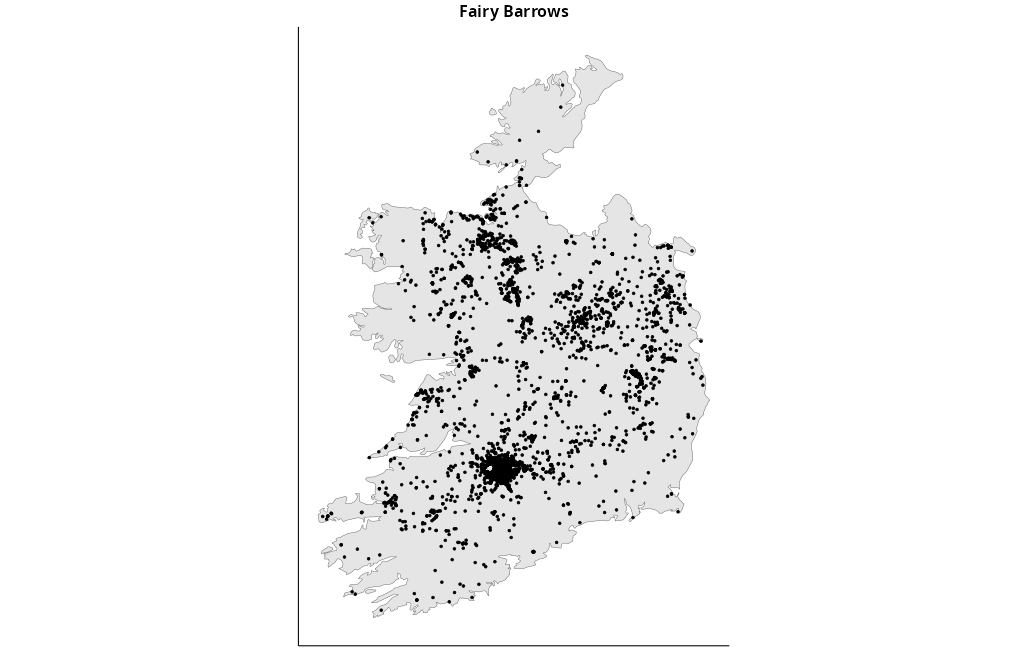

# Land Cover Data Preparation

# Exploratory Data Analysis

# Hypothesis Testing

# Discussion

# Conclusion